# DB2 DMS × Potts (`potts_ft_bound_minus_unbound`) — Figures

## Imports

In [2]:
import math
import re
from collections import defaultdict

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

mpl.rcParams.update({
    'font.family':         'sans-serif',
    'font.size':           11,
    'axes.linewidth':      1.2,
    'xtick.major.width':   1.2,
    'ytick.major.width':   1.2,
    'xtick.major.size':    5,
    'ytick.major.size':    5,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'figure.dpi':          300,
})

GRAY = '#D4D4D4'


## Configuration

In [3]:
# Inputs (all in working directory)
DMS_FILE   = 'db2_dms_results_flexible_smart_300bp.csv'
POTTS_FILE = 'potts_ft_DB2_RelE_minus_db2_only.csv'
PDB_FILE   = 'DB2_RelE.pdb'           # only needed for interface analysis (§6, §7)

# Model identifier — used for output filenames and column naming
SELECTED_MODEL     = 'potts_ft_bound_minus_unbound'
selected_model_col = f'potts_ddG_{SELECTED_MODEL}'

# DB2 protein sequence (residues 1–73, no leading methionine)
DB2_SEQUENCE = "SALEKALEELKKEFEGYDVRVITREQLTPEEIEALERLRELAWKAADGEEVDEEEARRLVERLKEALARIYAK"

# Floor extreme depletion in log2 enrichment
ENRICHMENT_FLOOR = -15

# Mutant amino acids displayed on the y-axis of the stacked heatmaps
DISPLAYED_AMINO_ACIDS = ['A', 'D', 'F', 'K', 'L', 'S', 'V']

# Seed-grafted positions in the SwanSeed RFdiffusion design
SEED_POSITIONS = set(range(16, 23)) | set(range(42, 49))

# Inter-chain contact cutoff (Å) for interface definition
INTERFACE_CUTOFF_A = 4.0


## 1. Merge DMS and Potts predictions

In [4]:
def parse_dms_variant(variant_id):
    """Parse 'DB2_DMS_28TA' → (position, wildtype, mutant, is_wildtype)."""
    if variant_id == 'DB2_DMS_WT':
        return None, None, None, True
    m = re.search(r'DB2_DMS_(\d+)([A-Z])([A-Z])', variant_id)
    if m:
        return int(m.group(1)), m.group(2), m.group(3), False
    return None, None, None, False


def extract_mutation_from_sequences(mutant_seq, wildtype_seq):
    """Compare 'DB2:RelE' colon-delimited pairs; return (position, wt_aa, mut_aa)."""
    m_parts, w_parts = mutant_seq.split(':'), wildtype_seq.split(':')
    if len(m_parts) != 2 or len(w_parts) != 2:
        return None, None, None
    m_db2, w_db2 = m_parts[0], w_parts[0]
    if len(m_db2) != len(w_db2):
        return None, None, None
    diffs = [(i + 1, w, m) for i, (m, w) in enumerate(zip(m_db2, w_db2)) if m != w]
    return diffs[0] if len(diffs) == 1 else (None, None, None)


# ── DMS ────────────────────────────────────────────────────────────────────
dms_df = pd.read_csv(DMS_FILE)
print(f"Loaded DMS:    {len(dms_df):>5} rows from {DMS_FILE}")

dms_parsed = dms_df['variant_id'].apply(
    lambda x: pd.Series(parse_dms_variant(x),
                        index=['position', 'wildtype', 'mutant', 'is_wildtype'])
)
dms_df = pd.concat([dms_df, dms_parsed], axis=1)
dms_df['merge_key'] = dms_df.apply(
    lambda r: f"{int(r['position'])}_{r['wildtype']}{r['mutant']}"
              if pd.notna(r['position']) else 'wildtype',
    axis=1,
)

# ── Potts ──────────────────────────────────────────────────────────────────
potts_df = pd.read_csv(POTTS_FILE)
print(f"Loaded Potts:  {len(potts_df):>5} rows from {POTTS_FILE}")

required = {'mutant', 'wildtype', 'ddG_pred'}
missing  = required - set(potts_df.columns)
if missing:
    raise ValueError(f"Potts CSV missing required columns: {missing}")

potts_parsed = potts_df.apply(
    lambda r: pd.Series(extract_mutation_from_sequences(r['mutant'], r['wildtype']),
                        index=['position', 'wt_aa', 'mut_aa']),
    axis=1,
)
potts_df = pd.concat([potts_df, potts_parsed], axis=1)
potts_df = potts_df[potts_df['position'].notna()].copy()
potts_df['merge_key'] = potts_df.apply(
    lambda r: f"{int(r['position'])}_{r['wt_aa']}{r['mut_aa']}", axis=1
)
print(f"  Potts: {len(potts_df)} parseable single-residue mutations")

# ── Merge ──────────────────────────────────────────────────────────────────
df = dms_df.merge(
    potts_df[['merge_key', 'ddG_pred']].rename(columns={'ddG_pred': selected_model_col}),
    on='merge_key', how='left',
)

# Wildtype rows have ΔΔG = 0 by definition (both global and per-position synonymous)
mask_wt = df['is_wildtype'] | (df['wildtype'] == df['mutant'])
df.loc[mask_wt, selected_model_col] = 0.0

# Apply enrichment floor
df['log2_enrichment'] = df['log2_enrichment'].clip(lower=ENRICHMENT_FLOOR)

n_pred = df[selected_model_col].notna().sum()
print(f"\nMerged: {len(df)} rows; "
      f"{n_pred} ({100 * n_pred / len(df):.1f}%) have a Potts prediction or are WT (ΔΔG=0)")
print(f"Applied ENRICHMENT_FLOOR = {ENRICHMENT_FLOOR}")


Loaded DMS:      477 rows from db2_dms_results_flexible_smart_300bp.csv
Loaded Potts:   2926 rows from potts_ft_DB2_RelE_minus_db2_only.csv
  Potts: 1387 parseable single-residue mutations

Merged: 477 rows; 477 (100.0%) have a Potts prediction or are WT (ΔΔG=0)
Applied ENRICHMENT_FLOOR = -15


## 2. Derived per-mutation columns


In [5]:
# Per-position WT enrichment lookup
wt_er = (df[df['wildtype'] == df['mutant']]
         .set_index('position')['log2_enrichment']
         .to_dict())

if not wt_er and df['is_wildtype'].any():
    global_er = df.loc[df['is_wildtype'], 'log2_enrichment'].iloc[0]
    print(f"No per-position synonymous DMS variants found; "
          f"using global WT (ER={global_er:.3f}) as the reference for all positions.")
    wt_er = {pos: global_er for pos in range(1, len(DB2_SEQUENCE) + 1)}
elif df['is_wildtype'].any():
    # Backfill any missing positions with the global WT enrichment
    global_er = df.loc[df['is_wildtype'], 'log2_enrichment'].iloc[0]
    for pos in range(1, len(DB2_SEQUENCE) + 1):
        wt_er.setdefault(pos, global_er)

# Real mutations only
non_wt = df[(df['wildtype'] != df['mutant']) & df['position'].notna()].copy()
non_wt['position_int'] = non_wt['position'].astype(int)
non_wt['abs_delta_er'] = (non_wt['log2_enrichment']
                          - non_wt['position'].map(wt_er)).abs()
non_wt['abs_ddg']      = non_wt[selected_model_col].abs()

print(f"\nReal mutations: {len(non_wt)}")
print(f"  Position range: {non_wt['position_int'].min()} → {non_wt['position_int'].max()}")
print(f"  |ΔER|: median={non_wt['abs_delta_er'].median():.3f}, "
      f"mean={non_wt['abs_delta_er'].mean():.3f}")
print(f"  |ΔΔG|: median={non_wt['abs_ddg'].median():.3f}, "
      f"mean={non_wt['abs_ddg'].mean():.3f}")


No per-position synonymous DMS variants found; using global WT (ER=-0.536) as the reference for all positions.

Real mutations: 476
  Position range: 1 → 73
  |ΔER|: median=3.038, mean=4.437
  |ΔΔG|: median=1.391, mean=2.083


## 3. ΔΔG vs DMS log2-enrichment scatter

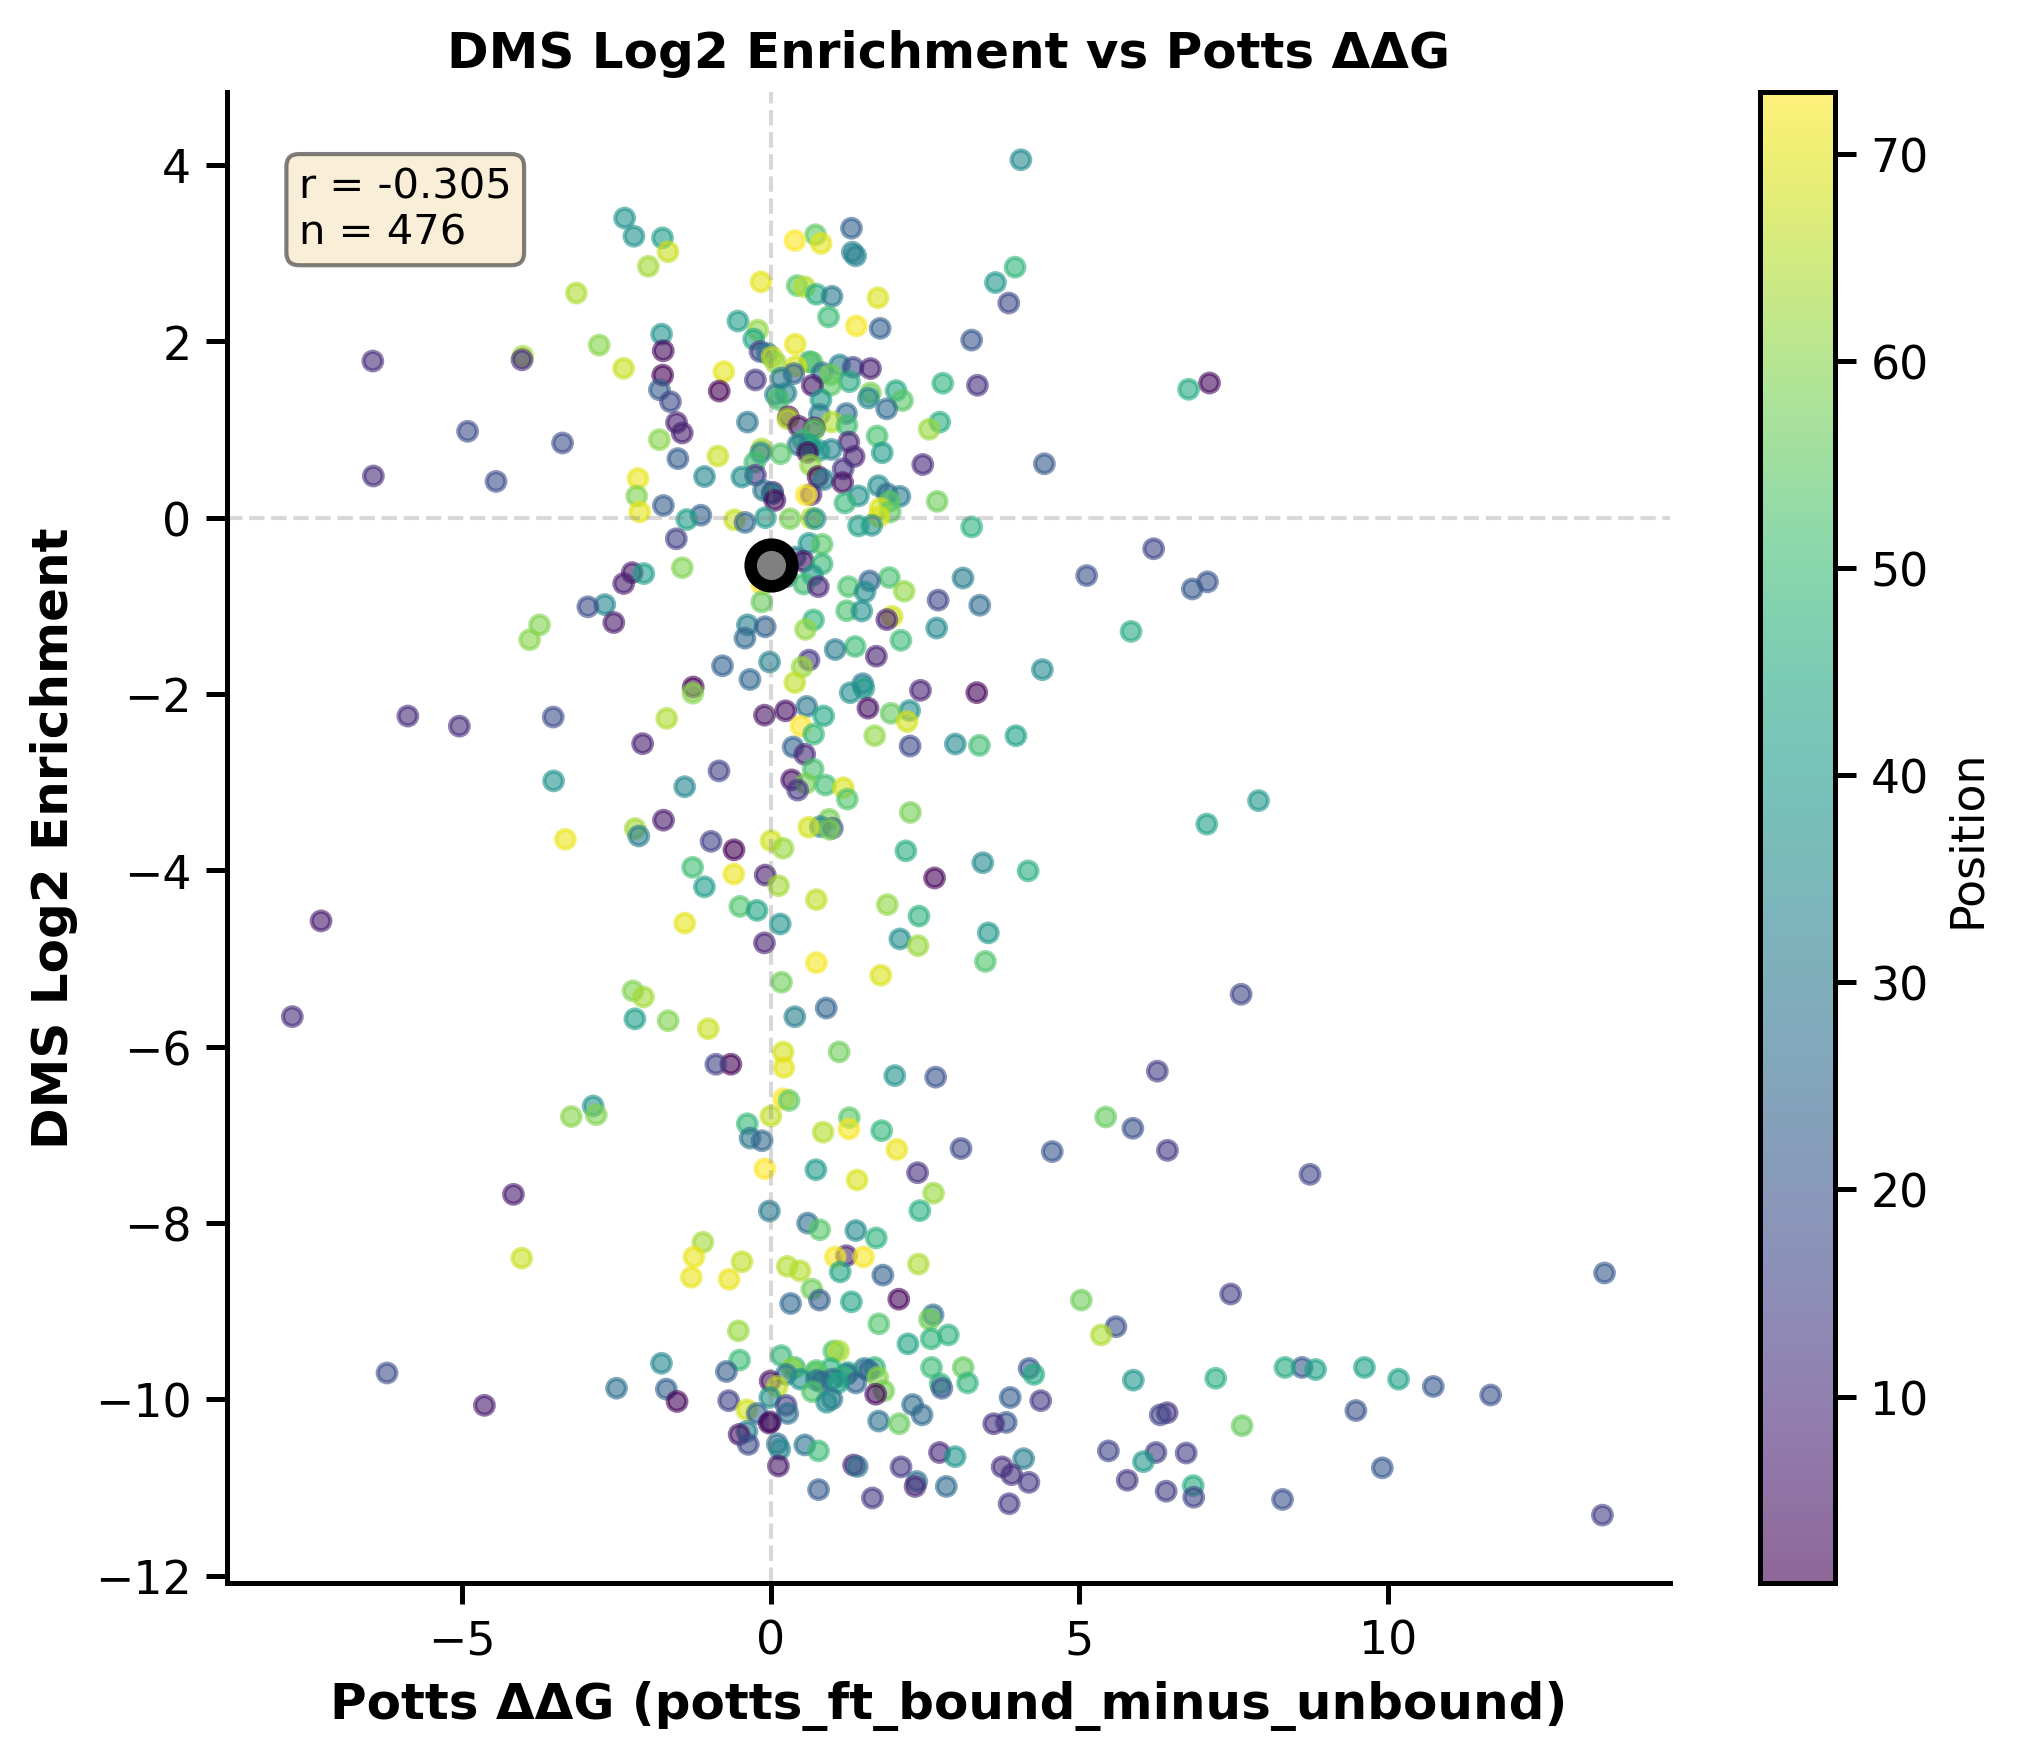

✓ scatter_log2enrichment_vs_ddG_potts_ft_bound_minus_unbound.png  (Pearson r = -0.3051, n = 476)


In [6]:
filtered_df = df[df['post_count'] >= 0].copy()
non_wt_scat = filtered_df[~filtered_df['is_wildtype']].copy()
wt_data     = filtered_df[ filtered_df['is_wildtype']].copy()
plot_df     = non_wt_scat[non_wt_scat[selected_model_col].notna()].copy()
plot_df['potts_ddG'] = plot_df[selected_model_col]

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(plot_df['potts_ddG'], plot_df['log2_enrichment'],
                c=plot_df['position'], cmap='viridis', alpha=0.6, s=20)

# Highlight wildtype reference if it has a Potts prediction
wt_with_model = wt_data[wt_data[selected_model_col].notna()]
if len(wt_with_model) > 0:
    wt_positions = wt_with_model['position'].values
    if len(wt_positions) > 0 and not pd.isna(wt_positions).all():
        ax.scatter(wt_with_model[selected_model_col], wt_with_model['log2_enrichment'],
                   c=wt_positions, cmap='viridis', s=100, marker='o',
                   edgecolors='black', linewidths=3, zorder=5)
    else:
        ax.scatter(wt_with_model[selected_model_col], wt_with_model['log2_enrichment'],
                   c='gray', s=100, marker='o',
                   edgecolors='black', linewidths=3, zorder=5)

ax.axhline(0, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axvline(0, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.set_xlabel(f'Potts ΔΔG ({SELECTED_MODEL})', fontsize=12, fontweight='bold')
ax.set_ylabel('DMS Log2 Enrichment',                     fontsize=12, fontweight='bold')
ax.set_title('DMS Log2 Enrichment vs Potts ΔΔG', fontsize=12, fontweight='bold')

corr = plot_df[['log2_enrichment', 'potts_ddG']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'r = {corr:.3f}\nn = {len(plot_df)}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.colorbar(sc, ax=ax, label='Position')
plt.tight_layout()
plt.savefig(f'scatter_log2enrichment_vs_ddG_{SELECTED_MODEL}.png',
            dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ scatter_log2enrichment_vs_ddG_{SELECTED_MODEL}.png  "
      f"(Pearson r = {corr:.4f}, n = {len(plot_df)})")


## 4. Stacked positional heatmaps

Top: mean DMS log2-enrichment by (position, mutant).  
Bottom: mean Potts ΔΔG.  
X-axis labels show the wildtype residue at each position; y-axis is restricted to `DISPLAYED_AMINO_ACIDS`.

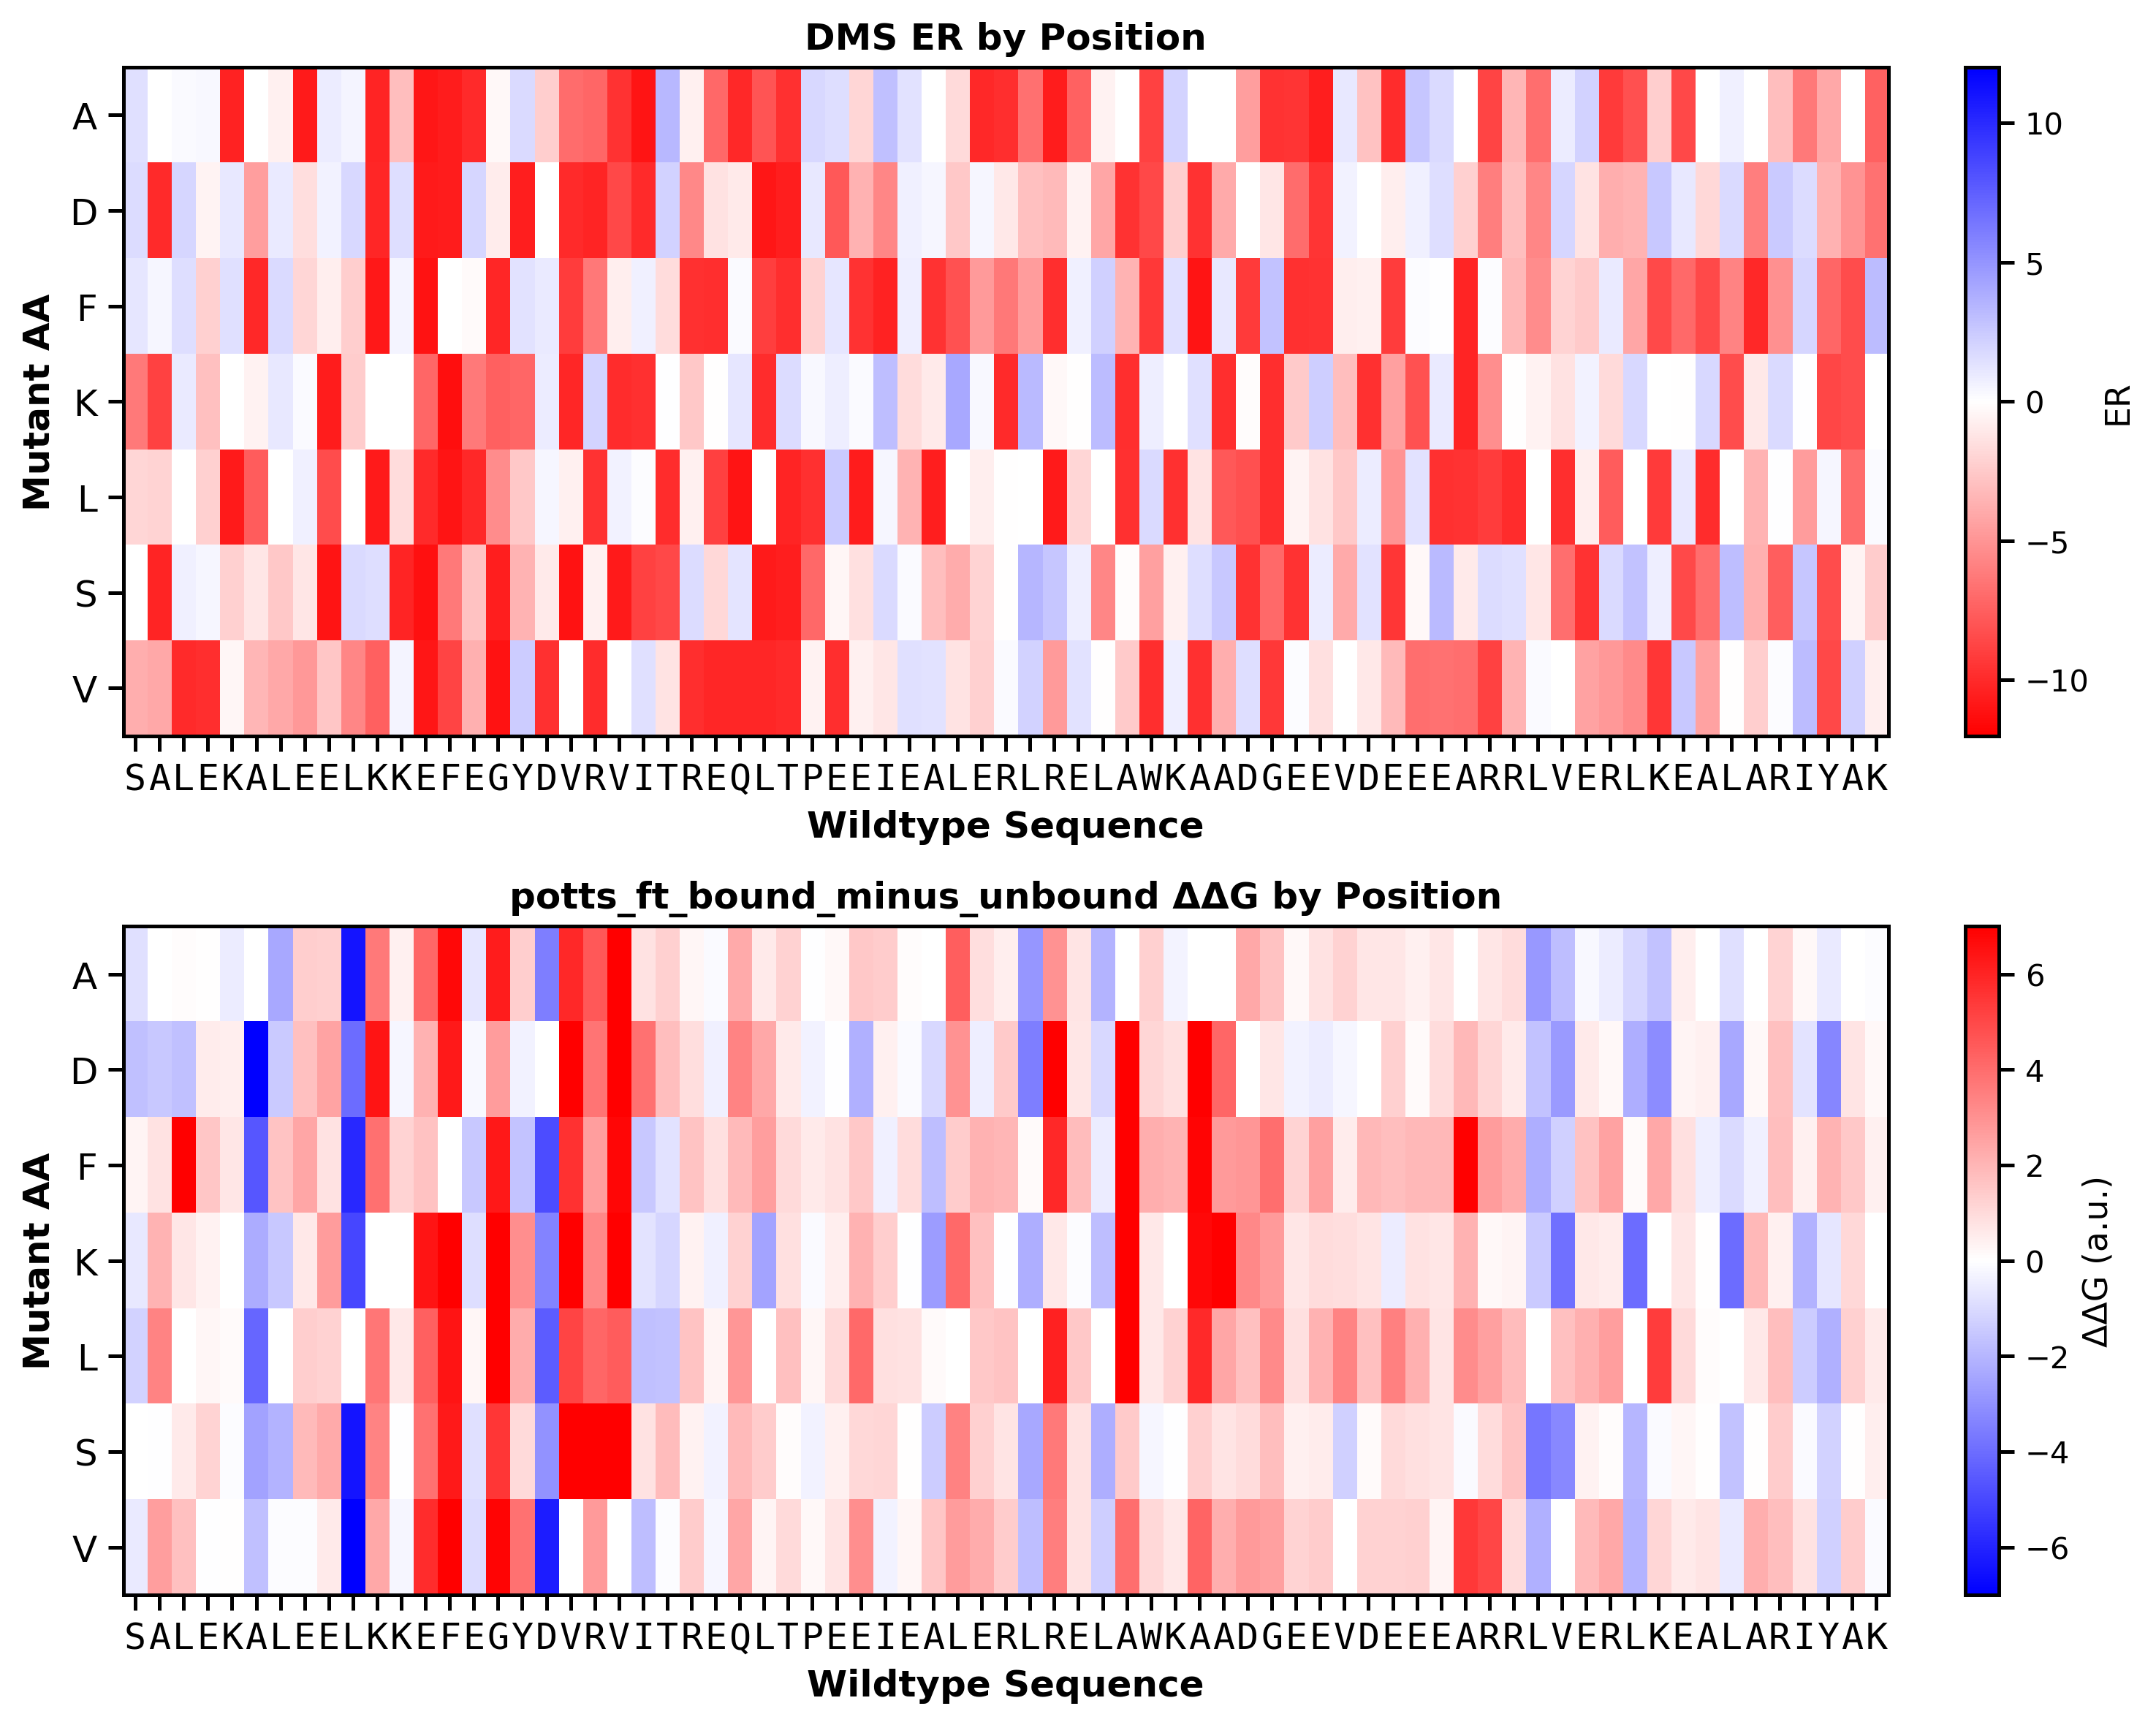

✓ positional_heatmaps_stacked_potts_ft_bound_minus_unbound.png


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# --- DMS ER ----------------------------------------------------------------
log2_pivot = (non_wt
              .pivot_table(values='log2_enrichment', index='mutant',
                           columns='position', aggfunc='mean')
              .loc[lambda p: p.index.intersection(DISPLAYED_AMINO_ACIDS)])

im1 = axes[0].imshow(log2_pivot.values, cmap='bwr_r', aspect='auto', vmin=-12, vmax=12)
axes[0].set_yticks(range(len(log2_pivot.index)))
axes[0].set_yticklabels(log2_pivot.index, fontsize=12)
axes[0].set_ylabel('Mutant AA', fontsize=12, fontweight='bold')
axes[0].set_title('DMS ER by Position', fontsize=12, fontweight='bold')

positions = [int(x) for x in log2_pivot.columns]
axes[0].set_xticks(range(len(log2_pivot.columns)))
axes[0].set_xticklabels([DB2_SEQUENCE[p - 1] for p in positions],
                        fontsize=12, family='monospace')
axes[0].set_xlabel('Wildtype Sequence', fontsize=12, fontweight='bold')
for spine in axes[0].spines.values():
    spine.set_visible(True); spine.set_linewidth(1.2)
cbar1 = plt.colorbar(im1, ax=axes[0], label='ER', fraction=0.046, pad=0.04)
cbar1.ax.tick_params(labelsize=10)

# --- Potts ΔΔG -------------------------------------------------------------
potts_pivot = (non_wt
               .pivot_table(values=selected_model_col, index='mutant',
                            columns='position', aggfunc='mean')
               .loc[lambda p: p.index.intersection(DISPLAYED_AMINO_ACIDS)])

im2 = axes[1].imshow(potts_pivot.values, cmap='bwr', aspect='auto', vmin=-7, vmax=7)
axes[1].set_yticks(range(len(potts_pivot.index)))
axes[1].set_yticklabels(potts_pivot.index, fontsize=12)
axes[1].set_ylabel('Mutant AA', fontsize=12, fontweight='bold')
axes[1].set_title(f'{SELECTED_MODEL} ΔΔG by Position',
                  fontsize=12, fontweight='bold')

positions = [int(x) for x in potts_pivot.columns]
axes[1].set_xticks(range(len(potts_pivot.columns)))
axes[1].set_xticklabels([DB2_SEQUENCE[p - 1] for p in positions],
                        fontsize=12, family='monospace')
axes[1].set_xlabel('Wildtype Sequence', fontsize=12, fontweight='bold')
for spine in axes[1].spines.values():
    spine.set_visible(True); spine.set_linewidth(1.2)
cbar2 = plt.colorbar(im2, ax=axes[1], label='ΔΔG (a.u.)',
                     fraction=0.046, pad=0.04)
cbar2.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(f'positional_heatmaps_stacked_{SELECTED_MODEL}.png',
            dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ positional_heatmaps_stacked_{SELECTED_MODEL}.png")


## Single-row heatmap helper

Shared renderer for the next three figures. The colorbar uses the white→red half of `bwr` for non-negative quantities (|ΔER|, |ΔΔG|) and the full diverging `bwr` for ρ.

In [8]:
_HALF_BWR = LinearSegmentedColormap.from_list(
    'white_red', plt.cm.bwr(np.linspace(0.5, 1.0, 256))
)


def single_row_heatmap(values, positions, *, cbar_label, diverging=False,
                       vmin=None, vmax=None, savepath=None):
    """Render a 1×N positional heatmap with wildtype-letter x-tick labels."""
    arr = np.asarray(values, dtype=float).reshape(1, -1)
    fig, ax = plt.subplots(figsize=(18, 1.8))

    if diverging:
        v_lo = -1 if vmin is None else vmin
        v_hi =  1 if vmax is None else vmax
        ax.imshow(arr, cmap='bwr', aspect='auto', vmin=v_lo, vmax=v_hi)
        sm = mpl.cm.ScalarMappable(cmap='bwr',
                                   norm=mpl.colors.Normalize(vmin=v_lo, vmax=v_hi))
    else:
        v_hi = np.nanmax(arr) if vmax is None else vmax
        # vmin set to -v_hi puts data on the white→red half of bwr
        ax.imshow(arr, cmap='bwr', aspect='auto', vmin=-v_hi, vmax=v_hi)
        sm = mpl.cm.ScalarMappable(cmap=_HALF_BWR,
                                   norm=mpl.colors.Normalize(vmin=0, vmax=v_hi))
    sm.set_array([])

    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(1.2)
    ax.set_yticks([]); ax.set_ylabel('')
    ax.set_xticks(range(len(positions)))
    ax.set_xticklabels([DB2_SEQUENCE[p - 1] for p in positions],
                       fontsize=14, family='monospace')
    ax.set_xlabel('Wildtype Sequence', fontsize=14, fontweight='bold')

    cbar = plt.colorbar(sm, ax=ax, fraction=0.3, pad=0.04, aspect=3)
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(cbar_label, fontsize=14, fontweight='bold')

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax


## 5. Per-position |ΔER| (single-row heatmap)

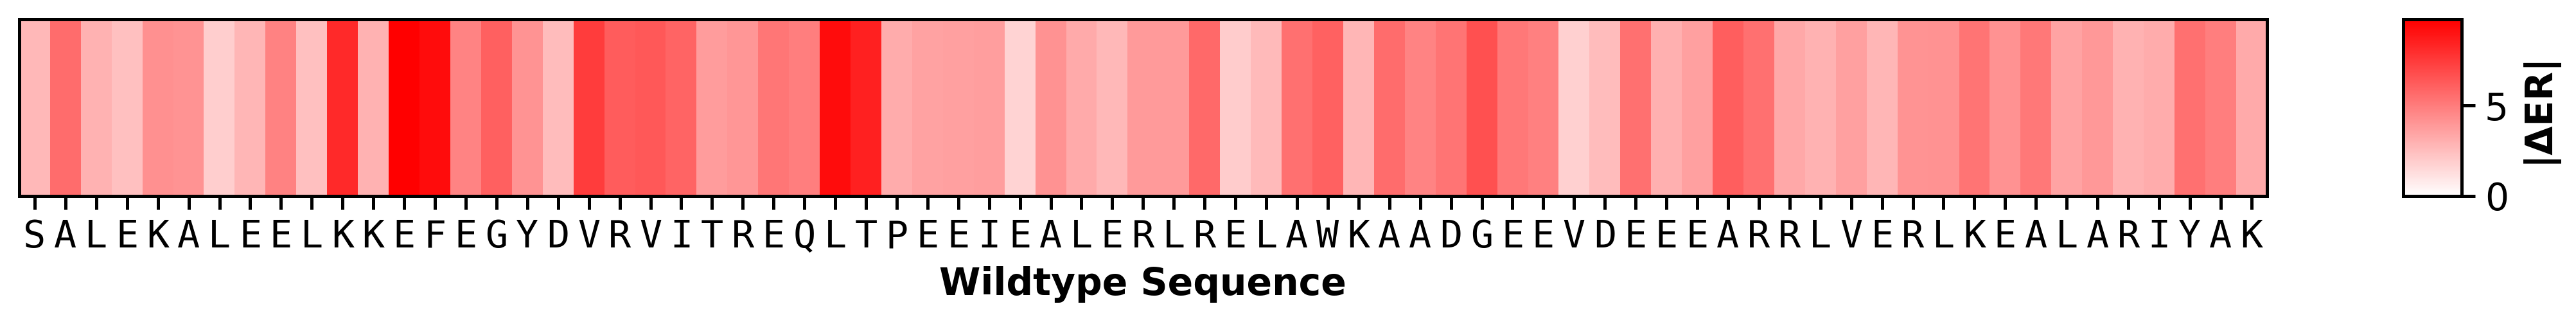

✓ abs_delta_er_heatmap_by_position.png


In [9]:
positions_list = sorted(non_wt['position_int'].unique())
pos_abs_der = [
    non_wt.loc[non_wt['position_int'] == p, 'abs_delta_er'].dropna().mean()
    if (non_wt['position_int'] == p).any() else np.nan
    for p in positions_list
]

single_row_heatmap(
    pos_abs_der, positions_list,
    cbar_label='|ΔER|',
    diverging=False,
    savepath='abs_delta_er_heatmap_by_position.png',
)
print("✓ abs_delta_er_heatmap_by_position.png")


## 6. Per-position |ΔΔG| (single-row heatmap)

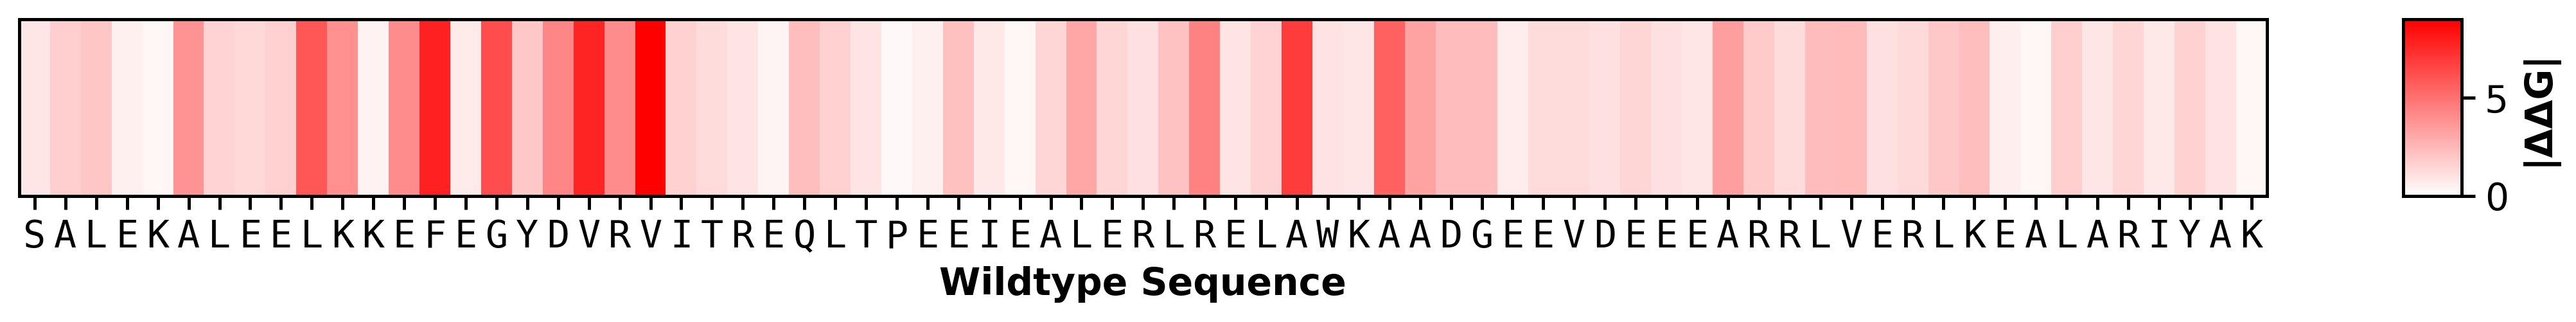

✓ abs_ddg_heatmap_by_position.png


In [10]:
positions_list = sorted(non_wt['position_int'].unique())
pos_abs_ddg = [
    non_wt.loc[non_wt['position_int'] == p, 'abs_ddg'].dropna().mean()
    if (non_wt['position_int'] == p).any() else np.nan
    for p in positions_list
]

single_row_heatmap(
    pos_abs_ddg, positions_list,
    cbar_label='|ΔΔG|',
    diverging=False,
    savepath='abs_ddg_heatmap_by_position.png',
)
print("✓ abs_ddg_heatmap_by_position.png")


## 7. Per-position Spearman ρ (ER vs ΔΔG) — single-row heatmap

Computed across **all** rows at each position (synonymous + mutations), matching the original analysis.

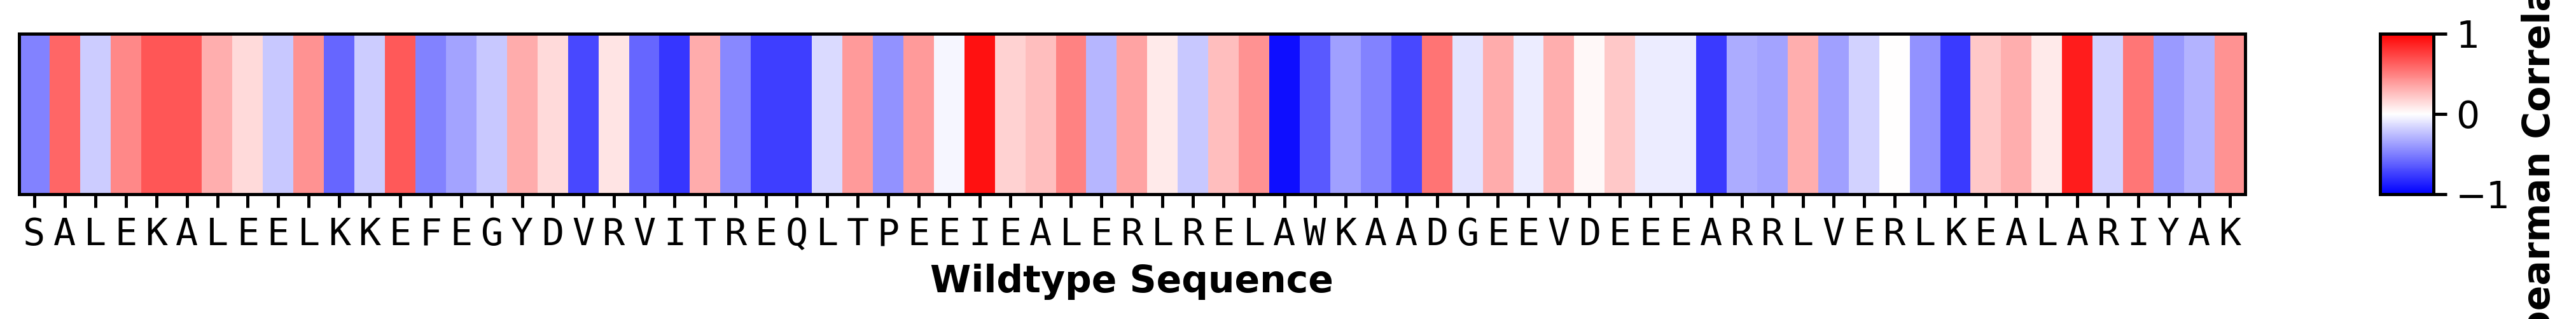

✓ spearman_correlation_heatmap_single_row_potts_ddG_potts_ft_bound_minus_unbound.png

Per-position Spearman ρ (ER vs ΔΔG, model: potts_ddG_potts_ft_bound_minus_unbound):
  Position  1 (S): ρ = -0.486  (n = 6)
  Position  2 (A): ρ =  0.600  (n = 6)
  Position  3 (L): ρ = -0.200  (n = 6)
  Position  4 (E): ρ =  0.464  (n = 7)
  Position  5 (K): ρ =  0.657  (n = 6)
  Position  6 (A): ρ =  0.657  (n = 6)
  Position  7 (L): ρ =  0.314  (n = 6)
  Position  8 (E): ρ =  0.143  (n = 7)
  Position  9 (E): ρ = -0.214  (n = 7)
  Position 10 (L): ρ =  0.429  (n = 6)
  Position 11 (K): ρ = -0.600  (n = 6)
  Position 12 (K): ρ = -0.200  (n = 6)
  Position 13 (E): ρ =  0.643  (n = 7)
  Position 14 (F): ρ = -0.486  (n = 6)
  Position 15 (E): ρ = -0.357  (n = 7)
  Position 16 (G): ρ = -0.214  (n = 7)
  Position 17 (Y): ρ =  0.321  (n = 7)
  Position 18 (D): ρ =  0.143  (n = 6)
  Position 19 (V): ρ = -0.714  (n = 6)
  Position 20 (R): ρ =  0.107  (n = 7)
  Position 21 (V): ρ = -0.600  (n = 6)
  Position 

In [11]:
all_data = df.dropna(subset=['position']).copy()
all_data['position_int'] = all_data['position'].astype(int)

positions_list = sorted(all_data['position_int'].unique())
position_corrs, position_n = [], []
for pos in positions_list:
    pos_data = (all_data[all_data['position_int'] == pos]
                [['log2_enrichment', selected_model_col]].dropna())
    if len(pos_data) > 2:
        r, _ = stats.spearmanr(pos_data['log2_enrichment'],
                               pos_data[selected_model_col])
        position_corrs.append(r)
    else:
        position_corrs.append(np.nan)
    position_n.append(len(pos_data))

single_row_heatmap(
    position_corrs, positions_list,
    cbar_label='Spearman Correlation ρ',
    diverging=True, vmin=-1, vmax=1,
    savepath=f'spearman_correlation_heatmap_single_row_{selected_model_col}.png',
)
print(f"✓ spearman_correlation_heatmap_single_row_{selected_model_col}.png")

# Per-position values
print(f"\nPer-position Spearman ρ (ER vs ΔΔG, model: {selected_model_col}):")
for pos, r, n in zip(positions_list, position_corrs, position_n):
    wt_aa = DB2_SEQUENCE[pos - 1]
    if not np.isnan(r):
        print(f"  Position {pos:2d} ({wt_aa}): ρ = {r:6.3f}  (n = {n})")
    else:
        print(f"  Position {pos:2d} ({wt_aa}): insufficient data  (n = {n})")


## 8. Interface positions (PDB parsing)

In [12]:
def parse_pdb(filepath):
    """Return all ATOM records as a list of dicts."""
    atoms = []
    with open(filepath) as f:
        for line in f:
            if line.startswith("ATOM"):
                atoms.append({
                    'name':    line[12:16].strip(),
                    'chain':   line[21],
                    'resid':   int(line[22:26]),
                    'x':       float(line[30:38]),
                    'y':       float(line[38:46]),
                    'z':       float(line[46:54]),
                    'element': line[76:78].strip() if len(line) > 76 else line[12:16].strip()[0],
                })
    return atoms


def chain_atoms_by_res(atoms, chain):
    """{resid -> [coord, ...]} for a given chain."""
    out = defaultdict(list)
    for a in atoms:
        if a['chain'] == chain:
            out[a['resid']].append(np.array([a['x'], a['y'], a['z']]))
    return out


atoms = parse_pdb(PDB_FILE)
a_all = chain_atoms_by_res(atoms, 'A')
b_all = chain_atoms_by_res(atoms, 'B')

interface_positions = set()
for res_a, coords_a in a_all.items():
    found = False
    for res_b, coords_b in b_all.items():
        for ca in coords_a:
            for cb in coords_b:
                if np.linalg.norm(ca - cb) <= INTERFACE_CUTOFF_A:
                    interface_positions.add(res_a)
                    found = True
                    break
            if found: break
        if found: break

interface_seed_positions = interface_positions & SEED_POSITIONS

print(f"Interface (any inter-chain contact ≤ {INTERFACE_CUTOFF_A} Å): n={len(interface_positions)}")
print(f"  {sorted(interface_positions)}")
print(f"Interface ∩ Seed: n={len(interface_seed_positions)}")
print(f"  {sorted(interface_seed_positions)}")


Interface (any inter-chain contact ≤ 4.0 Å): n=32
  [3, 6, 9, 10, 13, 14, 17, 18, 19, 20, 21, 22, 23, 24, 35, 36, 38, 39, 42, 43, 45, 46, 47, 51, 53, 56, 60, 63, 64, 67, 68, 71]
Interface ∩ Seed: n=11
  [17, 18, 19, 20, 21, 22, 42, 43, 45, 46, 47]


## 9. Interface progression boxplots (Non-Interface → Interface → Interface∩Seed)

Three side-by-side boxplots:
1. **|ΔER|** — magnitude of the experimental fitness perturbation
2. **|ΔΔG|** — magnitude of the Potts model prediction
3. **Spearman ρ** (negated, so positive = stabilizing-mutations-enriched) computed *per residue* across all mutations at that position

Significance brackets show two-sided Mann-Whitney U comparisons against the Non-Interface baseline (`*` p<0.05, `**` p<0.01, `***` p<0.001).

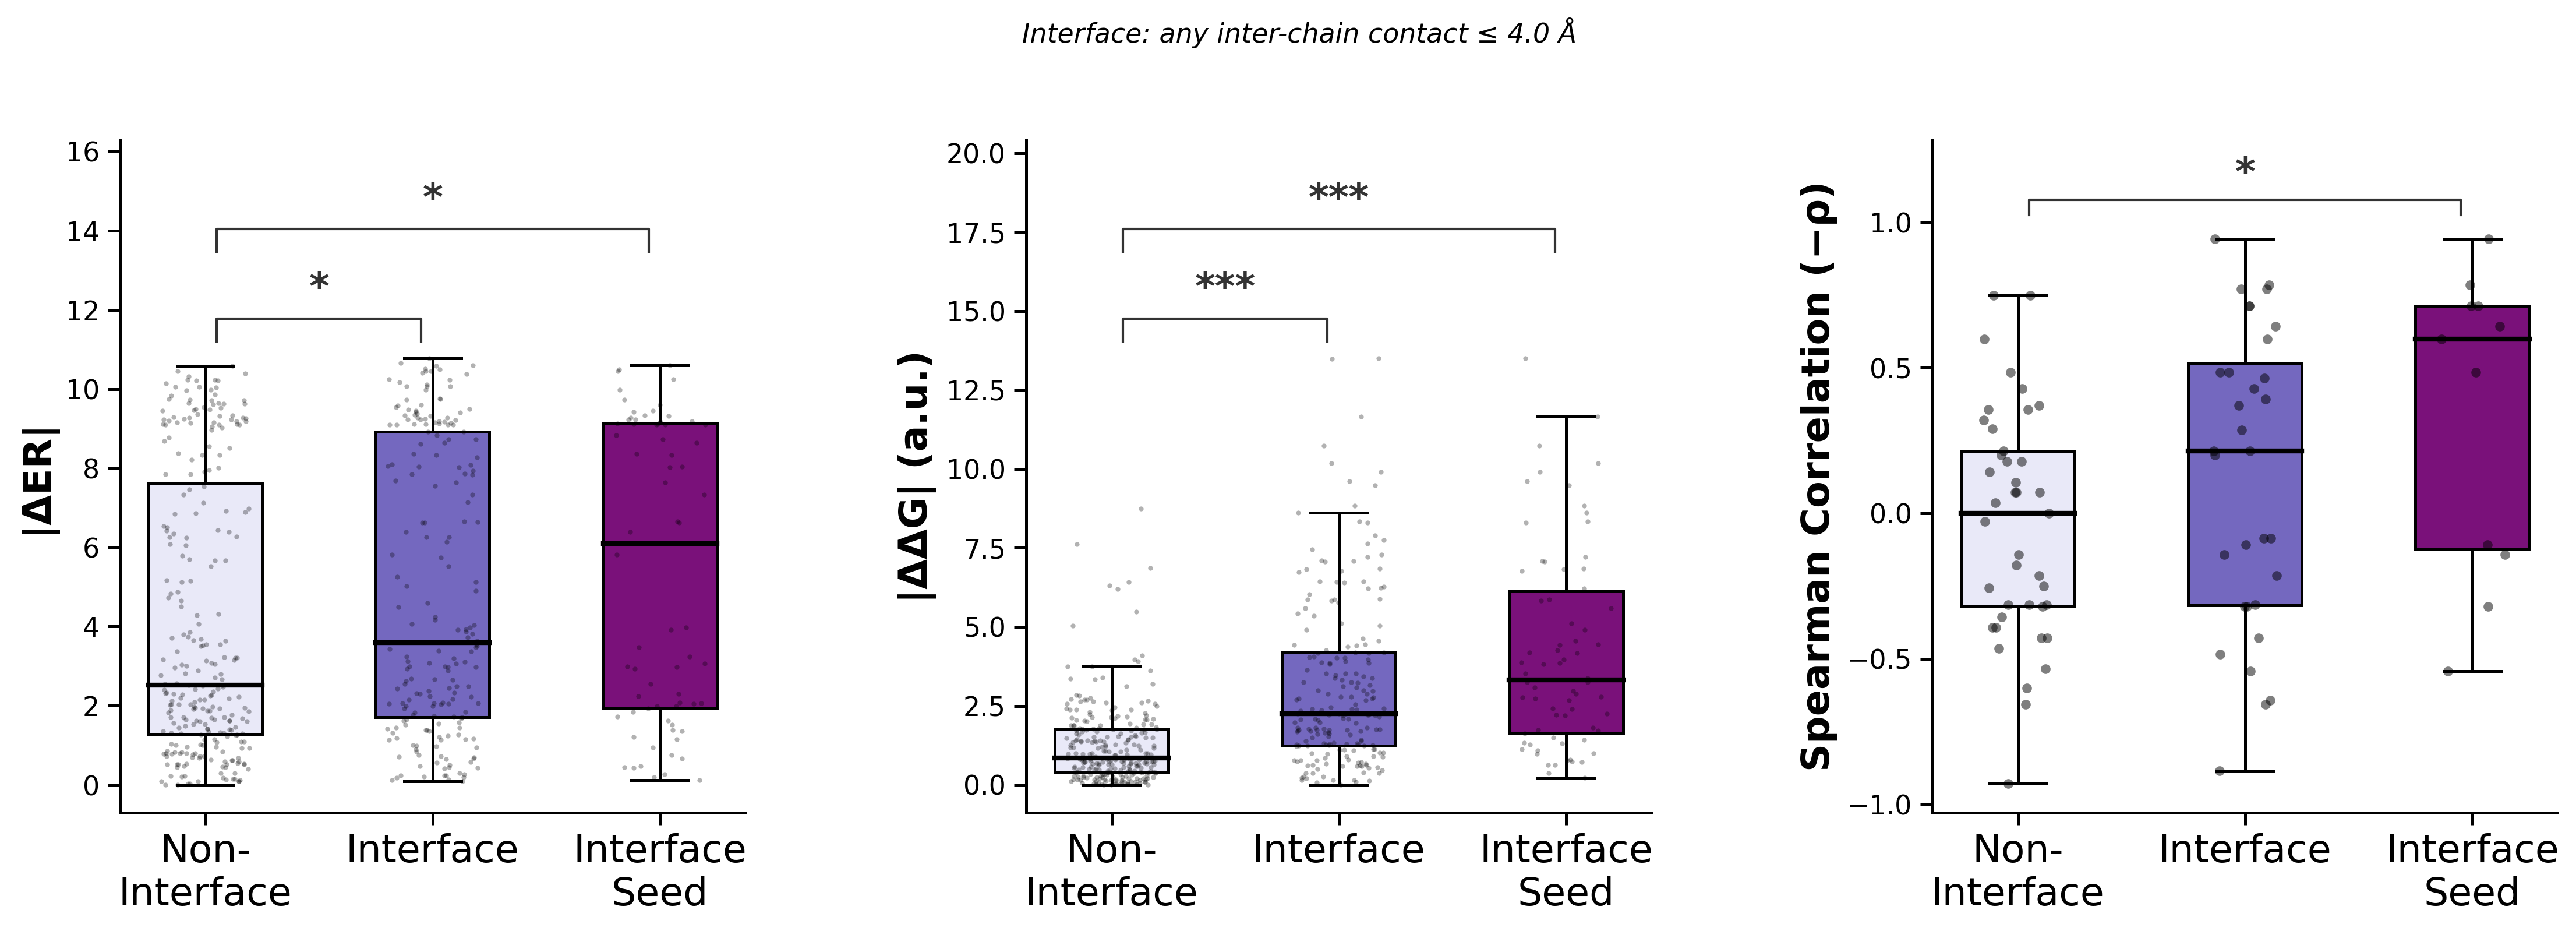


INTERFACE PROGRESSION (any contact ≤ 4.0 Å)

Non- Interface (n_pos=41):
  |ΔER|: median=2.522, mean=4.104 ± 0.211 (n_mut=272)
  |ΔΔG|: median=0.856, mean=1.281 ± 0.079 (n_mut=272)
  ρ:      median=0.0000, mean=0.0375 ± 0.062 (n_pos=41)

Interface (n_pos=32):
  |ΔER|: median=3.596, mean=4.880 ± 0.250 (n_mut=204)
  |ΔΔG|: median=2.247, mean=3.152 ± 0.188 (n_mut=204)
  ρ:      median=-0.2143, mean=-0.1328 ± 0.090 (n_pos=32)

Interface Seed (n_pos=11):
  |ΔER|: median=6.101, mean=5.426 ± 0.442 (n_mut=70)
  |ΔΔG|: median=3.314, mean=4.195 ± 0.377 (n_mut=70)
  ρ:      median=-0.6000, mean=-0.3429 ± 0.156 (n_pos=11)

MANN-WHITNEY U TESTS

Non- Interface vs Interface:
  |ΔER|: U=23948, p=0.01061 *
  |ΔΔG|: U=13843, p=7.996e-21 ***
  ρ:      U=804, p=0.1021 n.s.

Non- Interface vs Interface Seed:
  |ΔER|: U=7669, p=0.01213 *
  |ΔΔG|: U=3232, p=1.565e-17 ***
  ρ:      U=326, p=0.025 *


In [13]:
# Per-position Spearman ρ across ALL rows at each position
all_data = df.dropna(subset=['position']).copy()
all_data['position_int'] = all_data['position'].astype(int)

pos_raw_r = {}
for pos in sorted(all_data['position_int'].unique()):
    pos_data = (all_data[all_data['position_int'] == pos]
                [['log2_enrichment', selected_model_col]].dropna())
    if len(pos_data) > 2:
        r, _ = stats.spearmanr(pos_data['log2_enrichment'],
                               pos_data[selected_model_col])
        pos_raw_r[pos] = r

all_pos_set = set(pos_raw_r.keys())

# Group definitions
group_defs = {
    'Non-\nInterface': sorted(all_pos_set - interface_positions),
    'Interface':        sorted(all_pos_set & interface_positions),
    'Interface\nSeed': sorted(all_pos_set & interface_seed_positions),
}
colors    = ['lavender', 'slateblue', 'darkmagenta']
labels    = list(group_defs.keys())
label_idx = {label: i for i, label in enumerate(labels)}

# Per-group arrays
group_abs_der, group_abs_ddg, group_raw_r = {}, {}, {}
for label, positions in group_defs.items():
    pos_set = set(positions)
    mask = non_wt['position_int'].isin(pos_set)
    group_abs_der[label] = non_wt.loc[mask, 'abs_delta_er'].dropna().values
    group_abs_ddg[label] = non_wt.loc[mask, 'abs_ddg'].dropna().values
    group_raw_r[label]   = np.array([pos_raw_r[p] for p in positions if p in pos_raw_r])

# Long-form dataframes for seaborn
non_wt_grouped = pd.concat([
    non_wt[non_wt['position_int'].isin(set(positions))].assign(group=label)
    for label, positions in group_defs.items()
], ignore_index=True)

corr_df = pd.DataFrame([
    {'position': p, 'neg_r': -r, 'group': label}
    for p, r in pos_raw_r.items()
    for label, positions in group_defs.items()
    if p in positions
])


# ── Significance helpers ────────────────────────────────────────────────────
def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'


def add_sig_brackets(ax, data_dict, labels, negate=False):
    """Two-sided Mann-Whitney brackets vs the Non-Interface baseline."""
    pairs = [
        (label_idx['Non-\nInterface'], label_idx['Interface']),
        (label_idx['Non-\nInterface'], label_idx['Interface\nSeed']),
    ]

    sig_pairs = []
    for i, j in pairs:
        if len(data_dict[labels[i]]) < 2 or len(data_dict[labels[j]]) < 2:
            continue
        a, b = data_dict[labels[i]], data_dict[labels[j]]
        if negate: a, b = -a, -b
        _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        if p < 0.05:
            sig_pairs.append((i, j, p))
    if not sig_pairs:
        return

    sig_pairs.sort(key=lambda x: x[1] - x[0])
    layers = []
    for i, j, p in sig_pairs:
        for layer in layers:
            if all(j <= li or i >= lj for li, lj, _ in layer):
                layer.append((i, j, p)); break
        else:
            layers.append([(i, j, p)])

    y_max  = ax.get_ylim()[1]
    y_base = y_max * 1.04
    y_step = y_max * 0.2
    tick_h = y_step * 0.25
    inset  = 0.05
    for layer_i, layer in enumerate(layers):
        y_b = y_base + layer_i * y_step
        for i, j, p in layer:
            ax.plot([i + inset, i + inset, j - inset, j - inset],
                    [y_b - tick_h, y_b, y_b, y_b - tick_h],
                    color='#333', lw=1, zorder=5)
            ax.text((i + j) / 2, y_b + tick_h * 0.5, sig_label(p),
                    ha='center', va='bottom', fontsize=16,
                    fontweight='bold', color='#333')
    ax.set_ylim(ax.get_ylim()[0], y_base + len(layers) * y_step)


# ── Plot ───────────────────────────────────────────────────────────────────
box_kws = dict(
    showfliers=False, width=0.5, linewidth=1.2,
    boxprops=dict(edgecolor='black', linewidth=1.2),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black', linewidth=1.2),
    capprops=dict(color='black', linewidth=1.2),
)
palette = dict(zip(labels, colors))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5),
                                    gridspec_kw={'wspace': 0.45})

# Panel 1 — |ΔER|
sns.boxplot(data=non_wt_grouped.dropna(subset=['abs_delta_er']),
            x='group', y='abs_delta_er', order=labels,
            palette=palette, **box_kws, ax=ax1)
sns.stripplot(data=non_wt_grouped.dropna(subset=['abs_delta_er']),
              x='group', y='abs_delta_er', order=labels,
              color='black', size=2, alpha=0.3, jitter=0.2, ax=ax1)
ax1.set_xlabel(''); ax1.set_ylabel('|ΔER|', fontsize=16, fontweight='bold')
ax1.set_xticklabels(labels, fontsize=16)
add_sig_brackets(ax1, group_abs_der, labels, negate=False)

# Panel 2 — |ΔΔG|
sns.boxplot(data=non_wt_grouped.dropna(subset=['abs_ddg']),
            x='group', y='abs_ddg', order=labels,
            palette=palette, **box_kws, ax=ax2)
sns.stripplot(data=non_wt_grouped.dropna(subset=['abs_ddg']),
              x='group', y='abs_ddg', order=labels,
              color='black', size=2, alpha=0.3, jitter=0.2, ax=ax2)
ax2.set_xlabel(''); ax2.set_ylabel('|ΔΔG| (a.u.)', fontsize=16, fontweight='bold')
ax2.set_xticklabels(labels, fontsize=16)
add_sig_brackets(ax2, group_abs_ddg, labels, negate=False)

# Panel 3 — Spearman ρ (negated)
sns.boxplot(data=corr_df, x='group', y='neg_r', order=labels,
            palette=palette, **box_kws, ax=ax3)
sns.stripplot(data=corr_df, x='group', y='neg_r', order=labels,
              color='black', size=4, alpha=0.5, jitter=0.15, ax=ax3)
ax3.set_xlabel(''); ax3.set_ylabel('Spearman Correlation (−ρ)',
                                    fontsize=16, fontweight='bold')
ax3.set_xticklabels(labels, fontsize=16)
add_sig_brackets(ax3, group_raw_r, labels, negate=True)

plt.suptitle(f'Interface: any inter-chain contact ≤ {INTERFACE_CUTOFF_A} Å',
             fontsize=11, fontstyle='italic', y=1.02)
plt.savefig('interface_progression_any4A_boxplot_spearman.png',
            dpi=300, bbox_inches='tight', transparent=True)
plt.savefig('interface_progression_any4A_boxplot_spearman.pdf',
            bbox_inches='tight', transparent=True)
plt.show()


# ── Print statistics ───────────────────────────────────────────────────────
print(f"\n{'='*80}\nINTERFACE PROGRESSION (any contact ≤ {INTERFACE_CUTOFF_A} Å)\n{'='*80}")
for label in labels:
    n_pos = len(group_defs[label])
    der, ddg, r_vals = group_abs_der[label], group_abs_ddg[label], group_raw_r[label]
    sem = lambda x: np.std(x, ddof=1) / np.sqrt(len(x))
    clean = label.replace('\n', ' ')
    print(f"\n{clean} (n_pos={n_pos}):")
    print(f"  |ΔER|: median={np.median(der):.3f}, mean={np.mean(der):.3f} ± {sem(der):.3f} (n_mut={len(der)})")
    print(f"  |ΔΔG|: median={np.median(ddg):.3f}, mean={np.mean(ddg):.3f} ± {sem(ddg):.3f} (n_mut={len(ddg)})")
    print(f"  ρ:      median={np.median(r_vals):.4f}, mean={np.mean(r_vals):.4f} ± {sem(r_vals):.3f} (n_pos={len(r_vals)})")

print(f"\n{'='*80}\nMANN-WHITNEY U TESTS\n{'='*80}")
for a_label, b_label in [('Non-\nInterface', 'Interface'),
                          ('Non-\nInterface', 'Interface\nSeed')]:
    clean_a, clean_b = a_label.replace('\n', ' '), b_label.replace('\n', ' ')
    u_der, p_der = stats.mannwhitneyu(group_abs_der[a_label], group_abs_der[b_label], alternative='two-sided')
    u_ddg, p_ddg = stats.mannwhitneyu(group_abs_ddg[a_label], group_abs_ddg[b_label], alternative='two-sided')
    u_r,   p_r   = stats.mannwhitneyu(group_raw_r[a_label],   group_raw_r[b_label],   alternative='two-sided')
    print(f"\n{clean_a} vs {clean_b}:")
    print(f"  |ΔER|: U={u_der:.0f}, p={p_der:.4g} {sig_label(p_der)}")
    print(f"  |ΔΔG|: U={u_ddg:.0f}, p={p_ddg:.4g} {sig_label(p_ddg)}")
    print(f"  ρ:      U={u_r:.0f}, p={p_r:.4g} {sig_label(p_r)}")


## 10. PyMOL coloring scripts

Generates three `.pml` files that color chain A of `DB2_RelE.pdb` by:
1. Mean **|ΔER|** per position (white→red)
2. Mean **|ΔΔG|** per position (white→red)
3. Per-position **Spearman ρ** (blue→white→red)

Interface residues (any inter-chain contact ≤ 4 Å) are shown as sticks; `obj01` is rendered as a translucent white surface; chain B is hidden.

Run in PyMOL with `@pymol_color_<metric>.pml`.

In [14]:
# Per-position aggregates
pos_abs_der_dict = non_wt.groupby('position_int')['abs_delta_er'].mean().to_dict()
pos_abs_ddg_dict = non_wt.groupby('position_int')['abs_ddg'].mean().to_dict()
pos_raw_r_dict   = pos_raw_r  # already computed above

interface_resi_str = '+'.join(str(p) for p in sorted(interface_positions))


def write_pymol_script(filename, title, values_dict, cmap_name, vmin, vmax):
    """Write a PyMOL .pml that colors chain A by per-position values."""
    lines = [
        f'# {title}',
        f'# Values range: {vmin:.3f} to {vmax:.3f}',
        f'# Interface: any inter-chain contact <= {INTERFACE_CUTOFF_A} Angstrom',
        '',
        f'load {PDB_FILE}, DB2_RelE',
        '',
        '# Setup',
        'bg_color white',
        'set ray_opaque_background, 0',
        'set antialias, 2',
        'set ray_shadows, 0',
        '',
        '# Hide everything, show cartoon for DB2_RelE',
        'hide everything',
        'show cartoon, DB2_RelE',
        '',
        '# Hide chain B completely',
        'hide everything, chain B',
        '',
        '# Style obj01 as white transparent surface',
        'hide everything, obj01',
        'show surface, obj01',
        'color white, obj01',
        'set transparency, 0.4, obj01',
        '',
        '# Define interface selection',
        f'select interface, chain A and resi {interface_resi_str}',
        '',
        '# Show sticks for interface residues',
        'show sticks, interface',
        'hide sticks, interface and name c+n+o and not name ca',
        'set stick_radius, 0.15',
        '',
        '# Zero out all B-factors on chain A',
        'alter chain A, b=0',
        '',
        '# Set B-factors to per-position values on chain A',
    ]
    for pos in sorted(values_dict.keys()):
        lines.append(f'alter chain A and resi {pos}, b={values_dict[pos]:.4f}')
    lines += [
        '',
        '# Color by B-factor',
        f'spectrum b, {cmap_name}, chain A, minimum={vmin:.4f}, maximum={vmax:.4f}',
        '',
        'rebuild',
        'deselect',
        '',
        'orient chain A',
        'zoom all, 5',
    ]
    with open(filename, 'w') as f:
        f.write('\n'.join(lines))
    print(f'  Written: {filename}')


# Script 1: |ΔER|
vals = {pos: pos_abs_der_dict.get(pos, 0.0) for pos in range(1, 74)}
vmin, vmax = min(vals.values()), max(vals.values())
print(f'|ΔER| range: {vmin:.3f} – {vmax:.3f}; using max={math.ceil(vmax):.3f}')
write_pymol_script(
    'pymol_color_abs_dER.pml',
    'Color chain A by mean |dER| per position',
    vals, 'white_red', 0.0, math.ceil(vmax),
)

# Script 2: |ΔΔG|
vals = {pos: pos_abs_ddg_dict.get(pos, 0.0) for pos in range(1, 74)}
vmin, vmax = min(vals.values()), max(vals.values())
print(f'|ΔΔG| range: {vmin:.3f} – {vmax:.3f}; using max={math.ceil(vmax):.3f}')
write_pymol_script(
    'pymol_color_abs_ddG.pml',
    'Color chain A by mean |ddG| (bound_minus_unbound) per position',
    vals, 'white_red', 0.0, math.ceil(vmax),
)

# Script 3: Spearman ρ
vals = {pos: pos_raw_r_dict.get(pos, 0.0) for pos in range(1, 74)}
print(f'ρ range: {min(vals.values()):.3f} – {max(vals.values()):.3f}; fixed scale [-1, 1]')
write_pymol_script(
    'pymol_color_spearman_rho.pml',
    'Color chain A by per-position Spearman rho (ER vs ddG)',
    vals, 'blue_white_red', -1, 1,
)

print('\nDone! Run in PyMOL:')
print('  @pymol_color_abs_dER.pml')
print('  @pymol_color_abs_ddG.pml')
print('  @pymol_color_spearman_rho.pml')


|ΔER| range: 1.620 – 9.768; using max=10.000
  Written: pymol_color_abs_dER.pml
|ΔΔG| range: 0.274 – 9.004; using max=10.000
  Written: pymol_color_abs_ddG.pml
ρ range: -0.943 – 0.929; fixed scale [-1, 1]
  Written: pymol_color_spearman_rho.pml

Done! Run in PyMOL:
  @pymol_color_abs_dER.pml
  @pymol_color_abs_ddG.pml
  @pymol_color_spearman_rho.pml
